## Fine-tuning Stable Diffusion XL with LoRA on Naruto Data

SDXL consists of a much larger UNet and two text encoders that make the cross-attention context quite larger than the previous variants. In this notebook we fine-tune this large model using LoRA.

## Install Dependencies

In [1]:
!git clone https://github.com/huggingface/diffusers

Cloning into 'diffusers'...
remote: Enumerating objects: 111488, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 111488 (delta 57), reused 35 (delta 30), pack-reused 111398 (from 2)
Receiving objects: 100% (111488/111488), 84.00 MiB | 14.69 MiB/s, done.
Resolving deltas: 100% (83143/83143), done.


In [2]:
%cd /content/diffusers
!pip install -e .
%cd examples/text_to_image
!pip install -r requirements_sdxl.txt
!pip install bitsandbytes

/content/diffusers
Obtaining file:///content/diffusers
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.36.0.dev0-0.editable-py3-none-any.whl size=11374 sha256=25f1b327e74a3f10b25a5cf59fd8979052ed5437c1a9f0ed5427c8747219dc68
  Stored in directory: /tmp/pip-ephem-wheel-cache-jz0uilgi/wheels/8a/fc/09/385efb77b455b2fd4a656c950079c93147e1f50ae614e51beb
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.35.2
    Uninstalling diffusers-0.35.2:
      Successfully uninstalled diffusers-0.35.2
/content/diffusers/examples/text_to_image
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 38.8 

In [3]:
# Fix locale issue sometimes seen in Colab + accelerate
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!accelerate config default
#   --enable_xformers_memory_efficient_attention \ Does not work below because of

accelerate configuration saved at /root/.cache/huggingface/accelerate/default_config.yaml


In [4]:
from huggingface_hub import notebook_login
notebook_login()


## Dataset
Appended " in Naruto animation style" to the captions of the Naruto dataset provided on HuggingFace

In [5]:
# Used the following script to append " in Naruto animation style" to the captions and save the new dataset to sprodem/naruto-style-sdxl
'''
from datasets import load_dataset
def append_naruto_style(example):
    example["text"] = example["text"] + " in Naruto animation style"
    return example

ds = load_dataset("lambdalabs/naruto-blip-captions", split="train")
ds = ds.map(append_naruto_style)
ds.push_to_hub("sprodem/naruto-style-sdxl")
'''

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

data/train-00000-of-00002-12944970063701(…):   0%|          | 0.00/344M [00:00<?, ?B/s]

...

New Data Upload               : |          |  0.00B /  0.00B            

                              :   6%|6         | 21.7MB /  357MB            

README.md:   0%|          | 0.00/321 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/sprodem/naruto-style-sdxl/commit/f96a927a217f2345a9c40f66c4c00cc86cb28658', commit_message='Upload dataset', commit_description='', oid='f96a927a217f2345a9c40f66c4c00cc86cb28658', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sprodem/naruto-style-sdxl', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sprodem/naruto-style-sdxl'), pr_revision=None, pr_num=None)

data/train-00000-of-00002.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/357M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1221 [00:00<?, ? examples/s]

1221


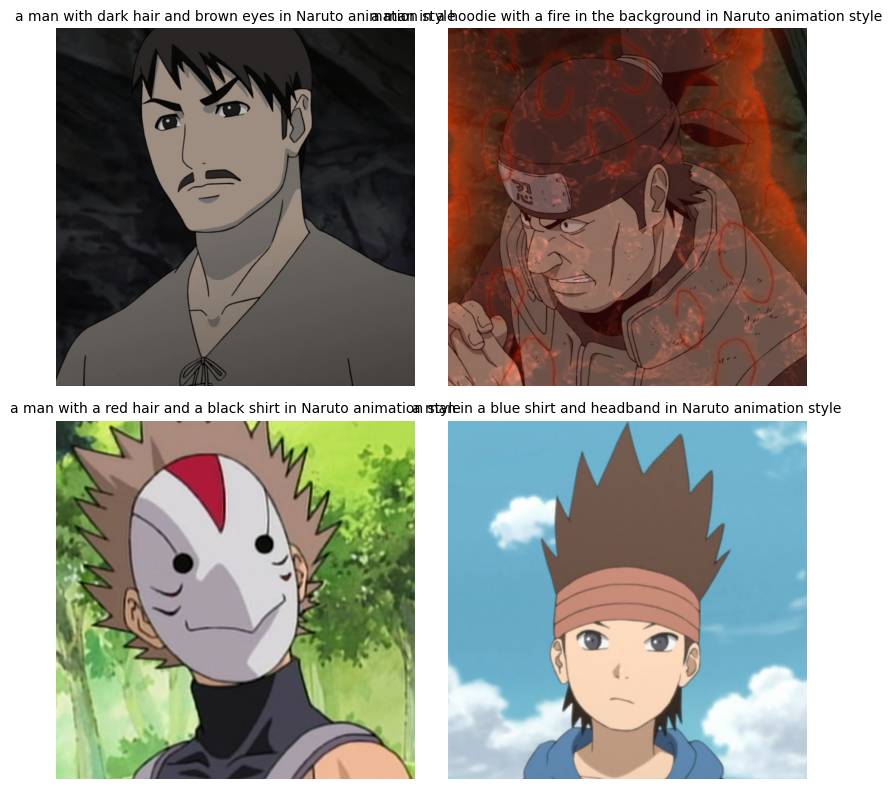

In [6]:

# Visualize the Data
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image
# Load dataset
dataset = load_dataset("sprodem/naruto-style-sdxl", split="train")
def show_samples(dataset, num_rows=2, num_cols=2):
    total = num_rows * num_cols
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 4*num_rows))
    for idx in range(total):
        example = dataset[idx]
        img = example["image"]
        caption = example["text"]
        r = idx // num_cols
        c = idx % num_cols
        axs[r][c].imshow(img)
        axs[r][c].set_title(caption, fontsize=10)
        axs[r][c].axis("off")

    plt.tight_layout()
    plt.show()
print(len(dataset))
show_samples(dataset)

## Training

In [10]:
!accelerate launch train_text_to_image_lora_sdxl.py \
  --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0" \
  --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix" \
  --dataset_name="sprodem/naruto-style-sdxl" \
  --use_8bit_adam \
  --image_column="image" \
  --caption_column="text" \
  --resolution=1024 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --rank=64 \
  --learning_rate=1e-4 \
  --max_train_steps=500 \
  --mixed_precision="fp16" \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --checkpointing_steps=25 \
  --validation_prompt="Naruto anime portrait style" \
  --validation_epochs=1 \
  --output_dir="sdxl-naruto-lora"

2025-11-20 08:09:07.797647: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-20 08:09:07.815461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763626147.836979    7257 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763626147.843461    7257 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763626147.859894    7257 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Save Model to Hub

In [12]:
from huggingface_hub import create_repo, upload_folder
from IPython.display import display, Markdown
import os

repo_id = "sprodem/sdxl-naruto-lora"   # Repo ID
output_dir = "sdxl-naruto-lora"

# Create repo if it does not exist
repo_id = create_repo(repo_id, exist_ok=True).repo_id

# 2. Model Card
model_card_text = f"""
# SDXL Naruto Style LoRA

This LoRA was trained using **train_text_to_image_lora_sdxl.py** on the dataset:
- `sprodem/naruto-style-sdxl`

## Training Details
- Base model: stabilityai/stable-diffusion-xl-base-1.0
- VAE: madebyollin/sdxl-vae-fp16-fix
- Resolution: 1024×1024
- Rank: 64
- Mixed precision: fp16
- Optimizer: 8-bit Adam
- Steps: 2 (example)
- Validation prompt: "Naruto anime portrait style"

## Usage

Load base SDXL:

`pipe = StableDiffusionXLPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16).to("cuda")`

Apply LoRA:

`pipe.load_lora_weights("{repo_id}")`

Generate an image:

`image = pipe("Naruto anime portrait style").images[0]`
"""

# Save model card
readme_path = os.path.join(output_dir, "README.md")
with open(readme_path, "w") as f:
    f.write(model_card_text)

# Upload Folder
upload_folder(
    repo_id=repo_id,
    folder_path=output_dir,
    commit_message="Upload SDXL Naruto LoRA",
    ignore_patterns=["step_*", "epoch_*"]
)

link_to_model = f"https://huggingface.co/{repo_id}"
display(Markdown(f"LoRA model is uploaded!\nAccess it here: {link_to_model}"))


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...heckpoint-1/scheduler.bin: 100%|##########| 1.40kB / 1.40kB            

  ...ra/checkpoint-1/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...ckpoint-100/scheduler.bin: 100%|##########| 1.40kB / 1.40kB            

...

  ...t-125/random_states_0.pkl: 100%|##########| 14.8kB / 14.8kB            

  ...t-100/random_states_0.pkl: 100%|##########| 14.8kB / 14.8kB            

  .../checkpoint-100/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ..._lora_weights.safetensors:   7%|6         | 25.1MB /  372MB            

LoRA model is uploaded!
Access it here: https://huggingface.co/sprodem/sdxl-naruto-lora